In [ ]:
import torch
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

In [ ]:
dataset = MNIST(root='data/', download = True)
print(len(dataset))

60000


# Loading dataset

In [ ]:
mnist_dataset = MNIST(root = '/data',download = True,train = True, transform=transforms.ToTensor())
print(mnist_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: /data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [ ]:
img_tensors, label = mnist_dataset[0]
print(img_tensors, label)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

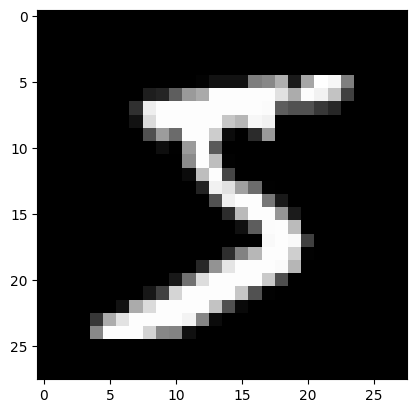

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img_tensors.squeeze(), cmap = 'gray')
plt.show()

In [ ]:
train_data, test_data = random_split(mnist_dataset, [50000, 10000])
print(len(train_data))
print(len(test_data))

50000
10000


# DataLoader

In [ ]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size, shuffle=True)
test_loader  = DataLoader(test_data, batch_size, shuffle=False)

In [ ]:
import torch.nn as nn
input_size = 28 * 28
num_classes = 10
# Logistic Regression Model
model = nn.Linear(input_size, num_classes)

print(model.weight)
print(model.weight.shape)
print(model.bias.shape)
print(model.bias)

Parameter containing:
tensor([[ 0.0238,  0.0016, -0.0190,  ...,  0.0333,  0.0294, -0.0181],
        [-0.0219, -0.0134,  0.0120,  ..., -0.0074, -0.0190,  0.0045],
        [-0.0024, -0.0137,  0.0175,  ...,  0.0221,  0.0050,  0.0103],
        ...,
        [ 0.0086,  0.0248, -0.0040,  ..., -0.0257, -0.0136,  0.0191],
        [ 0.0043,  0.0019,  0.0347,  ...,  0.0343,  0.0180,  0.0061],
        [ 0.0101, -0.0141, -0.0071,  ...,  0.0282,  0.0041, -0.0088]],
       requires_grad=True)
torch.Size([10, 784])
torch.Size([10])
Parameter containing:
tensor([ 0.0054, -0.0192, -0.0035, -0.0153, -0.0302,  0.0038, -0.0244, -0.0354,
        -0.0188,  0.0075], requires_grad=True)


In [ ]:
for images, labels in train_loader:
    print(labels)
    print(images.shape)
    outputs = model(images)
    break

tensor([1, 1, 8, 7, 6, 8, 8, 9, 6, 9, 6, 8, 9, 4, 4, 4, 5, 9, 6, 8, 2, 5, 2, 8,
        1, 9, 8, 7, 4, 8, 2, 6, 7, 1, 9, 1, 2, 7, 3, 0, 6, 8, 0, 7, 6, 9, 3, 5,
        3, 8, 4, 1, 5, 9, 2, 1, 8, 5, 3, 8, 1, 6, 3, 2, 2, 0, 2, 6, 7, 9, 6, 1,
        6, 8, 2, 7, 2, 4, 4, 7, 5, 3, 3, 7, 0, 6, 3, 0, 7, 8, 0, 0, 2, 5, 7, 3,
        8, 3, 7, 6, 0, 9, 0, 2, 3, 8, 1, 3, 7, 6, 1, 9, 6, 9, 7, 5, 7, 7, 8, 8,
        6, 2, 8, 1, 7, 5, 6, 9])
torch.Size([128, 1, 28, 28])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3584x28 and 784x10)

# Logistic Model

In [ ]:
class MnistModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(input_size, num_classes)

  def forward(self, xb):
    xb = xb.reshape(-1, 784)
    print(xb)
    out = self.linear(xb)
    print(out)
    return(out)

model = MnistModel()
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[ 0.0237, -0.0045,  0.0339,  ..., -0.0042, -0.0159,  0.0089],
         [-0.0070,  0.0348, -0.0044,  ...,  0.0098,  0.0214,  0.0021],
         [-0.0043,  0.0185,  0.0219,  ...,  0.0177, -0.0076, -0.0330],
         ...,
         [ 0.0340, -0.0263, -0.0133,  ...,  0.0268, -0.0228, -0.0065],
         [ 0.0010,  0.0167,  0.0322,  ...,  0.0122, -0.0009,  0.0098],
         [-0.0258,  0.0278, -0.0042,  ...,  0.0310, -0.0159, -0.0072]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0043,  0.0163,  0.0280,  0.0178, -0.0045,  0.0215,  0.0173,  0.0200,
          0.0312, -0.0101], requires_grad=True)]

In [ ]:
for img, label in train_loader:
  output = model(img)
  break

print('outputs shape: ', output.shape)
print('Sample outputs: \n', output[:2].data)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[-0.0216, -0.0258,  0.1063,  ...,  0.1352,  0.3087,  0.1877],
        [-0.1682,  0.1710,  0.0916,  ..., -0.0406,  0.2084,  0.0366],
        [-0.2238, -0.1158, -0.0223,  ..., -0.0145,  0.1869,  0.0609],
        ...,
        [-0.1651, -0.0245, -0.1008,  ...,  0.2458,  0.1599, -0.0783],
        [ 0.4394,  0.0588,  0.3508,  ...,  0.1205, -0.3415,  0.2014],
        [-0.1133, -0.1191,  0.2547,  ...,  0.1206, -0.1909,  0.1162]],
       grad_fn=<AddmmBackward0>)
outputs shape:  torch.Size([128, 10])
Sample outputs: 
 tensor([[-0.0216, -0.0258,  0.1063, -0.0595,  0.1132,  0.1156,  0.0055,  0.1352,
          0.3087,  0.1877],
        [-0.1682,  0.1710,  0.0916, -0.3901,  0.1892, -0.1284, -0.0603, -0.0406,
          0.2084,  0.0366]])


Make values between 0 to 1 usign softmax function

In [ ]:
import torch.nn.functional as F
probs = F.softmax(output, dim=1)
## chaecking at sample probabilities
print("Sample probabilities:\n", probs[:2].data)
print("\n")
## Add up the probabilities of an output row
print("Sum: ", torch.sum(probs[0]).item())
max_probs, preds = torch.max(probs, dim = 1)
print("\n")
print(preds)
print("\n")
print(max_probs)

Sample probabilities:
 tensor([[0.0892, 0.0888, 0.1014, 0.0859, 0.1021, 0.1023, 0.0917, 0.1044, 0.1241,
         0.1100],
        [0.0840, 0.1179, 0.1089, 0.0673, 0.1201, 0.0874, 0.0936, 0.0954, 0.1224,
         0.1031]])


Sum:  1.0


tensor([8, 8, 8, 2, 4, 4, 8, 8, 4, 4, 4, 7, 8, 7, 9, 0, 8, 8, 9, 8, 8, 9, 9, 2,
        8, 7, 2, 9, 8, 8, 1, 7, 8, 8, 8, 8, 4, 4, 9, 7, 4, 8, 8, 9, 4, 4, 8, 7,
        7, 8, 7, 6, 1, 8, 8, 8, 7, 4, 8, 8, 9, 7, 7, 7, 1, 8, 8, 9, 1, 7, 7, 7,
        4, 7, 7, 3, 8, 7, 8, 8, 7, 8, 9, 8, 8, 9, 8, 2, 8, 8, 7, 9, 7, 7, 3, 7,
        7, 0, 9, 7, 9, 4, 9, 7, 4, 7, 2, 8, 9, 8, 7, 8, 7, 9, 4, 4, 7, 7, 4, 4,
        9, 2, 8, 8, 8, 7, 0, 2])


tensor([0.1241, 0.1224, 0.1237, 0.1149, 0.1471, 0.1236, 0.1371, 0.1313, 0.1304,
        0.1259, 0.1148, 0.1261, 0.1438, 0.1277, 0.1315, 0.1182, 0.1265, 0.1319,
        0.1366, 0.1291, 0.1599, 0.1475, 0.1313, 0.1338, 0.1189, 0.1213, 0.1267,
        0.1418, 0.1568, 0.1268, 0.1227, 0.1172, 0.1249, 0.1192, 0.1548, 0.1276,
        0

In [ ]:
def accuracy(output, labels):
  _ , preds = torch.max(output, dim = 1)
  return(torch.tensor(torch.sum(preds == labels).item()/ len(preds)))

print("Accuracy: ", accuracy(output, labels))
print("\n")
loss_fn = F.cross_entropy
print("Loss Function: ",loss_fn)
print("\n")
## Loss for the current batch
loss = loss_fn(output, labels)
print(loss)

Accuracy:  tensor(0.1016)


Loss Function:  <function cross_entropy at 0x7b3908164b80>


tensor(2.3116, grad_fn=<NllLossBackward0>)
